In [2]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/wknn_experiment_3'

errors_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

print(config)

errors_df

{'max_wknn_k': 20, 'rf_param': 'sinr', 'operator_choice': [1, 10, 50, 88], 'n_runs': 20, 'campaigns': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40], 'runtime': 12472.674046993256}


,rf_param,wknn_k,runtime,errors,complexity
0,sinr,1,20.679571,0.711879,2327106.0
1,sinr,1,20.679571,8.409520,2327106.0
2,sinr,1,20.679571,0.165531,2327106.0
3,sinr,1,20.679571,0.111195,2327106.0
4,sinr,1,20.679571,4.893048,2327106.0
...,...,...,...,...,...
8066315,rssi,20,9.158556,27.128780,2995968.0
8066316,rssi,20,9.158556,2.896876,2995968.0
8066317,rssi,20,9.158556,5.903730,2995968.0
8066318,rssi,20,9.158556,5.232296,2995968.0


In [14]:
import pandas as pd
import numpy as np

# Assuming errors_df is your DataFrame
# Iterate over each group defined by the combination of 'rf_param' and 'wknn_k'
for name, group in errors_df.groupby(['rf_param', 'wknn_k']):
    group_size = len(group) // 20
    remainder = len(group) % 20
    groups = []

    # Create group assignments
    for i in range(20):
        size = group_size + (1 if i < remainder else 0)
        groups.extend([i] * size)

    # Shuffle groups to ensure randomness
    np.random.shuffle(groups)

    # Assign group numbers to the original DataFrame
    errors_df.loc[group.index, 'group'] = groups

# Display the modified DataFrame
means = errors_df.groupby(['rf_param', 'wknn_k', 'group']).mean().reset_index()

means

,rf_param,wknn_k,group,runtime,errors,complexity
0,rsrp,1,0.0,19.215278,4.092929,2.515944e+06
1,rsrp,1,1.0,19.002942,4.039196,2.515669e+06
2,rsrp,1,2.0,19.048437,4.244414,2.515386e+06
3,rsrp,1,3.0,19.057622,4.144634,2.515901e+06
4,rsrp,1,4.0,19.070531,4.100206,2.515555e+06
...,...,...,...,...,...,...
1595,sinr,20,15.0,17.221504,4.468415,2.330086e+06
1596,sinr,20,16.0,17.166475,4.623873,2.330031e+06
1597,sinr,20,17.0,17.077524,4.696939,2.329955e+06
1598,sinr,20,18.0,17.237088,4.495399,2.329970e+06


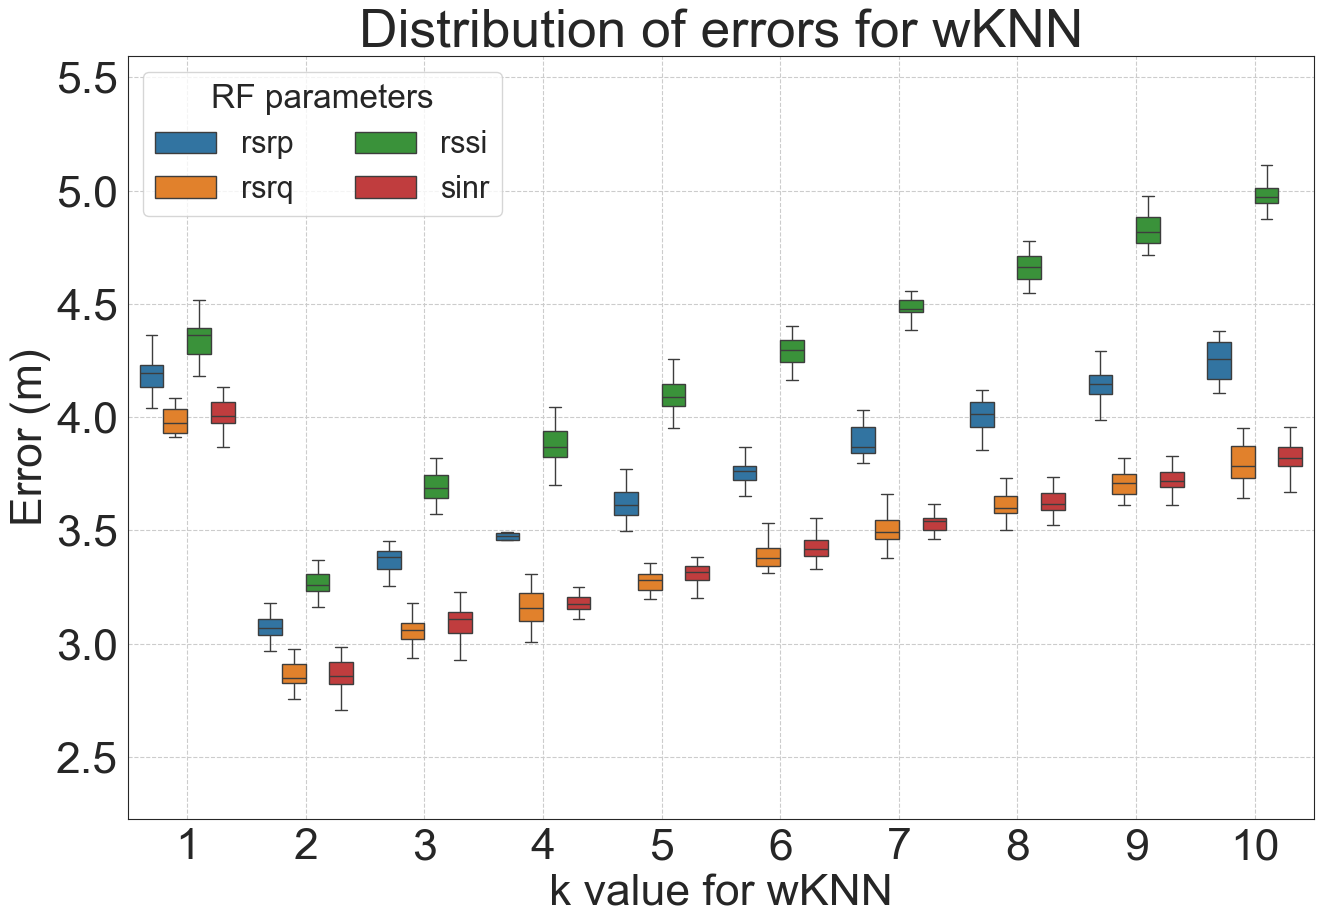

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot(df):
    plt.rcParams['font.size'] = 32
    plt.figure(figsize=(14, 10))

    df = df[df['wknn_k'] < 11]

    sns.set_style('white')
    sns.boxplot(data=df, x='wknn_k', width=0.8, y='errors', hue='rf_param', showfliers=False, )

    plt.grid(linestyle='--')
    plt.xlabel('k value for wKNN')
    plt.ylabel('Error (m)')
    plt.title('Distribution of errors for wKNN')

    plt.legend(title='RF parameters', loc='upper left', ncol=2, fontsize=22, title_fontsize=24)
    plt.margins(y=0.2)
    plt.tight_layout()
    plt.show()


plot(means)

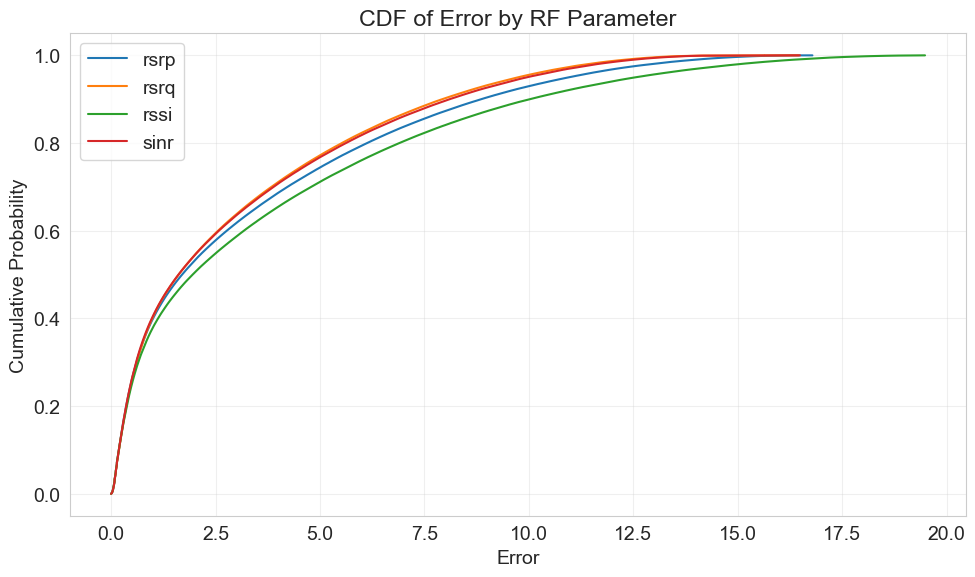

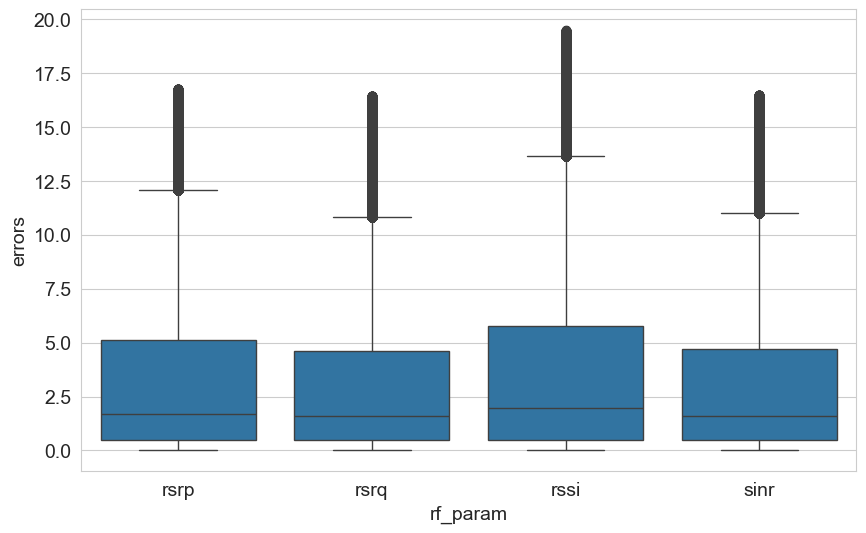

In [26]:
def remove_outliers_iqr(df, column, k=1.5):
    result_df = pd.DataFrame()

    # Group by both RF parameter and WKNN k value
    for (rf_param, wknn_k), group in df.groupby(['rf_param', 'wknn_k']):
        q1 = group[column].quantile(0.25)
        q3 = group[column].quantile(0.75)
        iqr = q3 - q1

        # Define bounds
        lower_bound = q1 - k * iqr
        upper_bound = q3 + k * iqr

        # Filter outliers
        filtered_group = group[(group[column] >= lower_bound) &
                               (group[column] <= upper_bound)]

        result_df = pd.concat([result_df, filtered_group])

    return result_df


data_df = errors_df[errors_df['wknn_k'] == 2]
data_df = remove_outliers_iqr(errors_df, 'errors')
# make cdf
import numpy as np

grouped = data_df.groupby('rf_param')

# Create a figure
plt.figure(figsize=(10, 6))

# Plot CDF for each RF parameter
for name, group in grouped:
    # Sort the error values
    sorted_errors = np.sort(group['errors'].values)
    # Calculate the CDF (y-axis values from 0 to 1)
    y_values = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

    # Plot the CDF line for this RF parameter
    plt.plot(sorted_errors, y_values, label=name)

# Add labels and title
plt.xlabel('Error')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Error by RF Parameter')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

plt.figure(figsize=(10, 6))

sns.boxplot(data_df, x='rf_param', y='errors', showfliers=True)

plt.show()

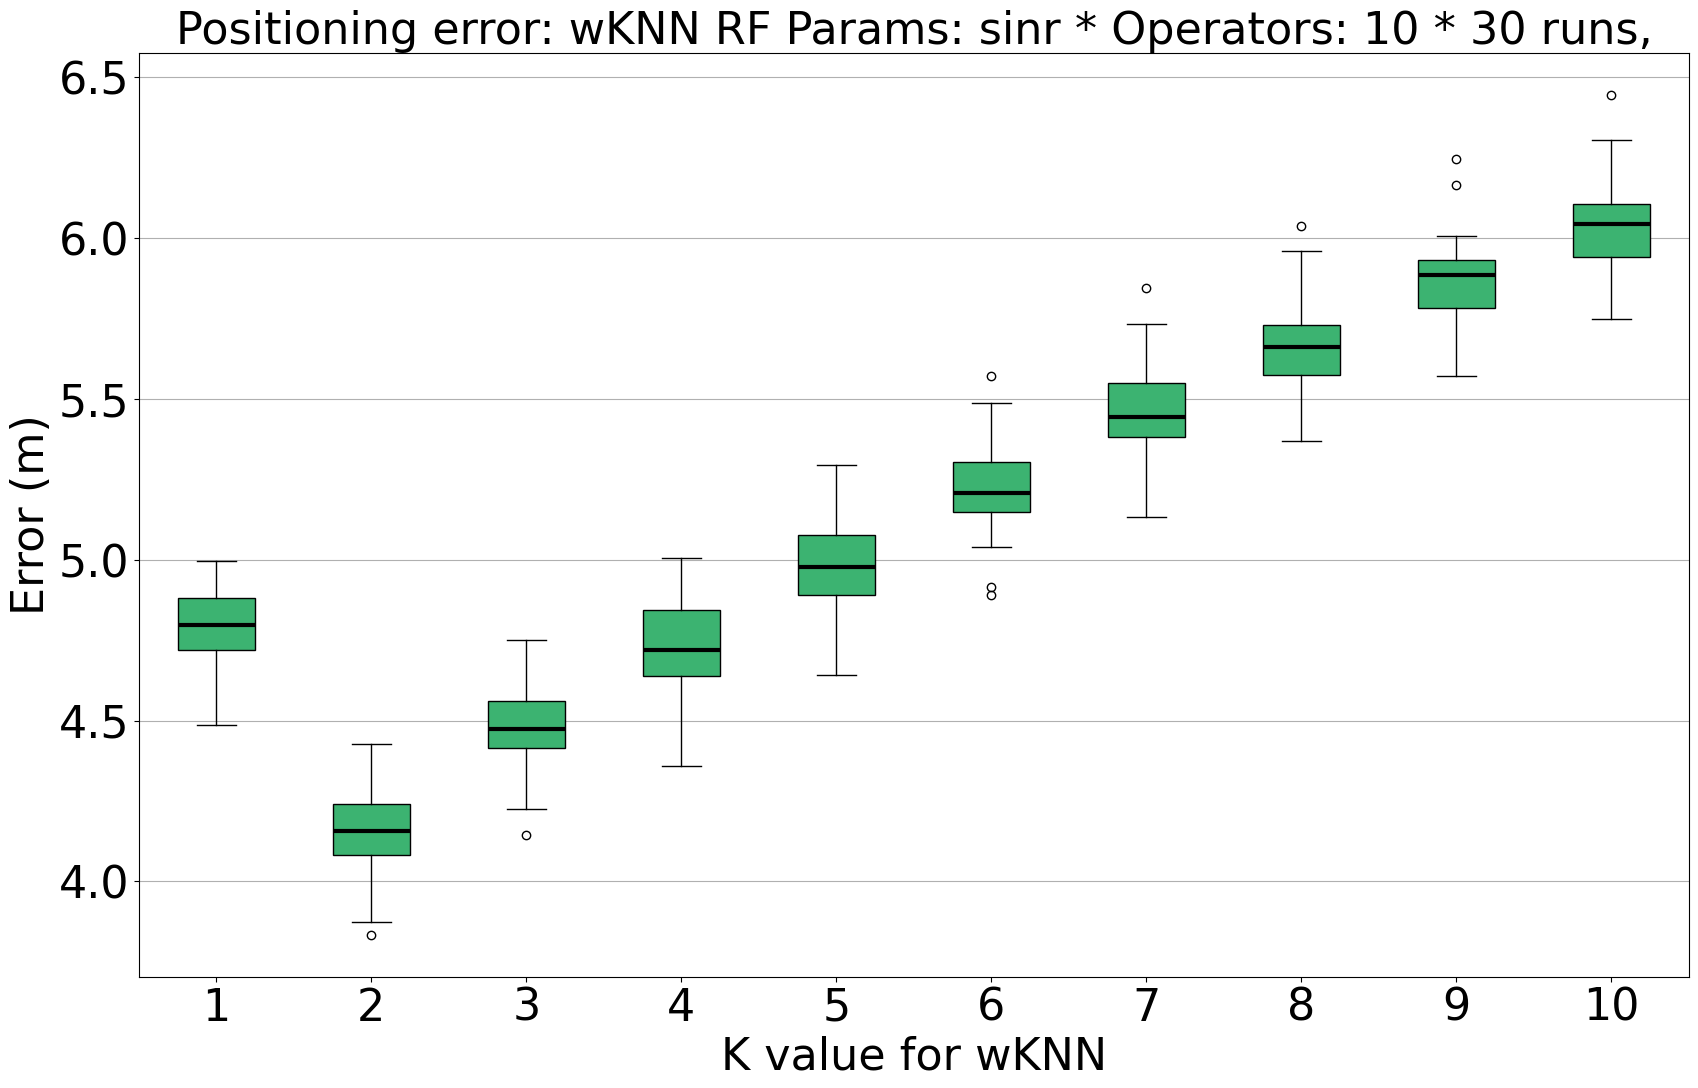

In [11]:
from scripts.utils import operators_to_str
from plotting.plotting import make_boxplot

param_str = f'RF Params: {config["rf_param"]}'
operator_str = f'Operators: {operators_to_str(config["operator_choice"])}'

title_string = f'wKNN {param_str} * {operator_str} * {config["n_runs"]} runs,'
make_boxplot(
    df=errors_df,
    title=f'Positioning error: {title_string}',
    x_label='K value for wKNN',
    y_label='Error (m)',
    color='mediumseagreen',
)
